# Results Analysis

Precision, Recall, and Accuracy across spurious conditions, grouped by model.

In [6]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

with open("../results/summary.json") as f:
    results = json.load(f)

CONDITIONS = [
    "pos0.0_neg0.5", "pos0.3_neg0.5",
    "pos0.5_neg0.0", "pos0.5_neg0.3"
]
DIFFICULTIES = ["obvious", "intermediate"]
SHAPES = ["circle", "wave"]
METRICS = ["precision", "recall"]
METRIC_COLORS = {"precision": "#4C72B0", "recall": "#DD8452", "accuracy": "#55A868"}
COND_LABELS = [c.replace("pos", "p=").replace("_neg", "\nn=") for c in CONDITIONS]


def plot_model(model):
    fig, axes = plt.subplots(
        len(DIFFICULTIES), len(SHAPES),
        figsize=(14, 8), sharey=True, sharex=False
    )
    bw = 0.8 / len(METRICS)
    x = np.arange(len(CONDITIONS))
    legend_handles = [
        mpatches.Patch(facecolor=METRIC_COLORS[m], label=m.capitalize())
        for m in METRICS
    ]
    for r, difficulty in enumerate(DIFFICULTIES):
        for c, shape in enumerate(SHAPES):
            ax = axes[r][c]
            for m_i, metric in enumerate(METRICS):
                offsets = x + (m_i - len(METRICS) / 2 + 0.5) * bw
                vals = [
                    results.get(f"{model}_{shape}_{difficulty}_{cond}", {}).get(metric, 0)
                    for cond in CONDITIONS
                ]
                ax.bar(offsets, vals, width=bw, color=METRIC_COLORS[metric],
                       alpha=0.85, edgecolor="white", linewidth=0.3)

            # Divider between "pos0.3_neg0.5" (idx 1) and "pos0.5_neg0.0" (idx 2)
            ax.axvline(1.5, color="black", linestyle="--", linewidth=0.8, alpha=0.6)

            ax.set_xticks(x)
            ax.set_xticklabels(COND_LABELS, fontsize=7)
            ax.set_ylim(0, 1.1)
            ax.yaxis.grid(True, linestyle="--", alpha=0.5)
            ax.set_axisbelow(True)
            if r == 0:
                ax.set_title(shape.capitalize(), fontsize=11, fontweight="bold")
            if c == 0:
                ax.set_ylabel(f"{difficulty.capitalize()}\nScore", fontsize=9)

    fig.legend(handles=legend_handles, loc="upper center", ncol=len(METRICS),
               fontsize=9, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(
        f"{model.upper()} — Precision, Recall & Accuracy by Spurious Condition",
        fontsize=13, fontweight="bold", y=1.06
    )
    plt.tight_layout()
    plt.savefig(f"../results/{model}_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"Loaded {len(results)} entries from summary.json")

Loaded 72 entries from summary.json


## AlexNet

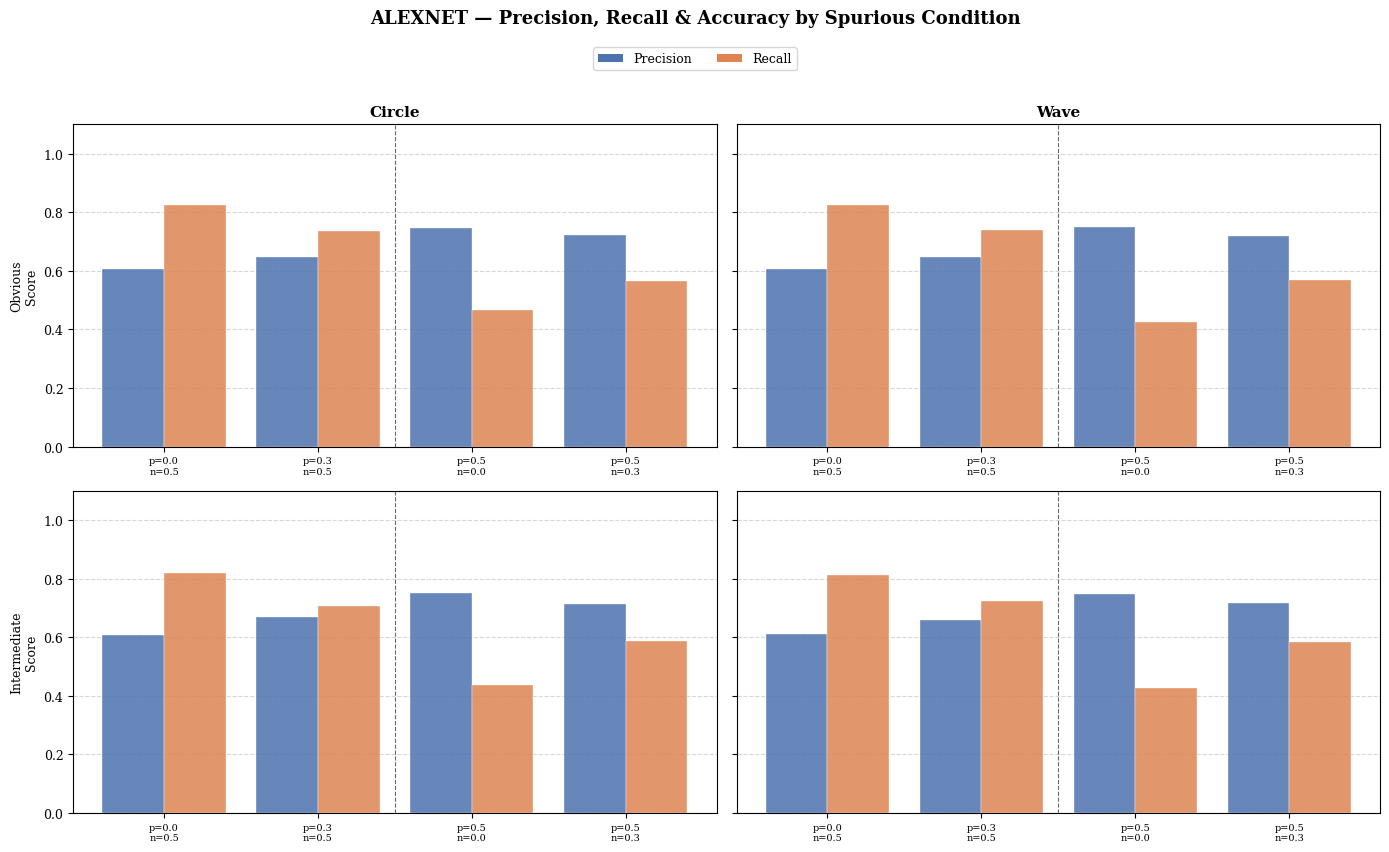

In [7]:
plot_model("alexnet")

## InceptionV3

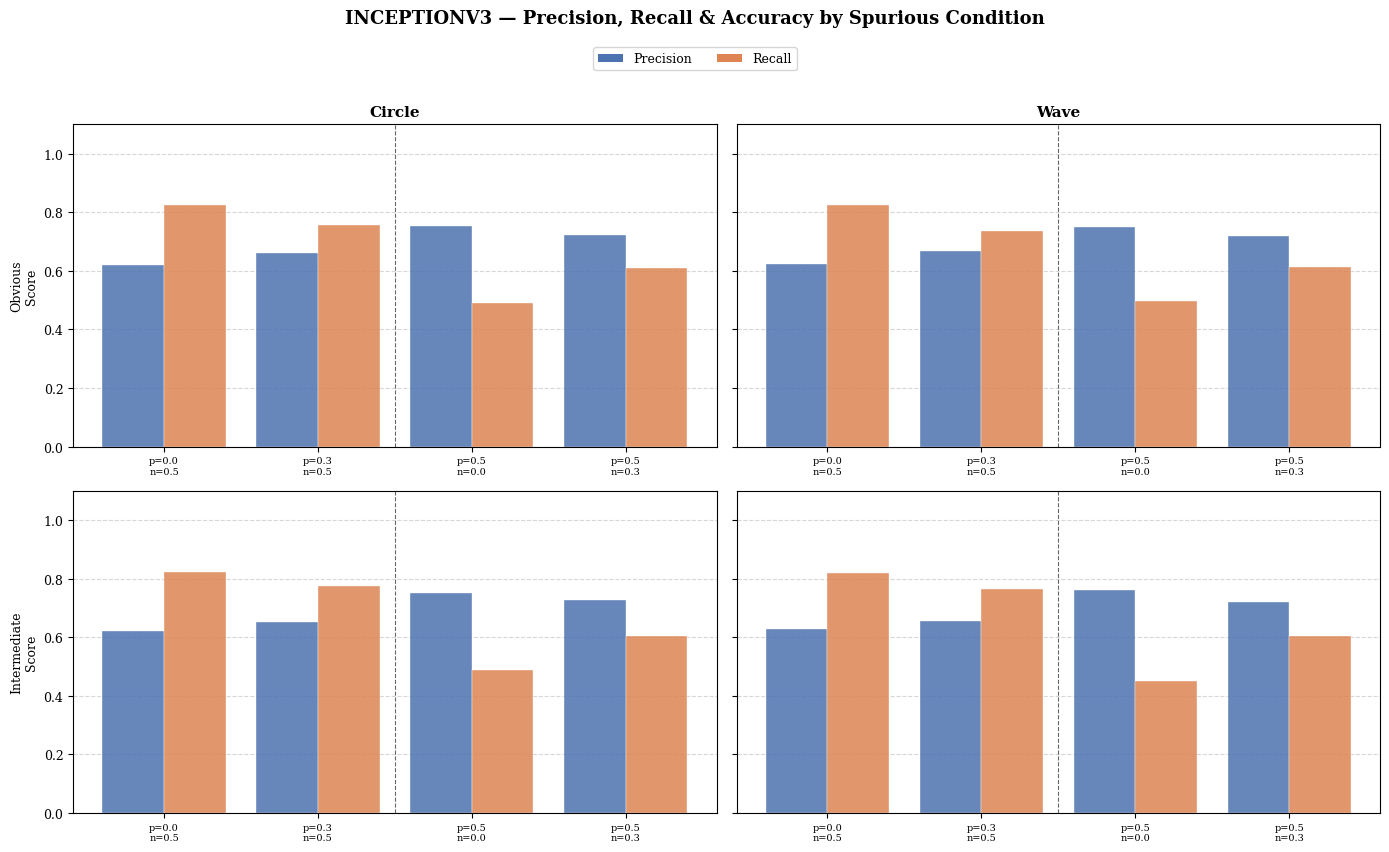

In [8]:
plot_model("inceptionv3")

## ResNet50

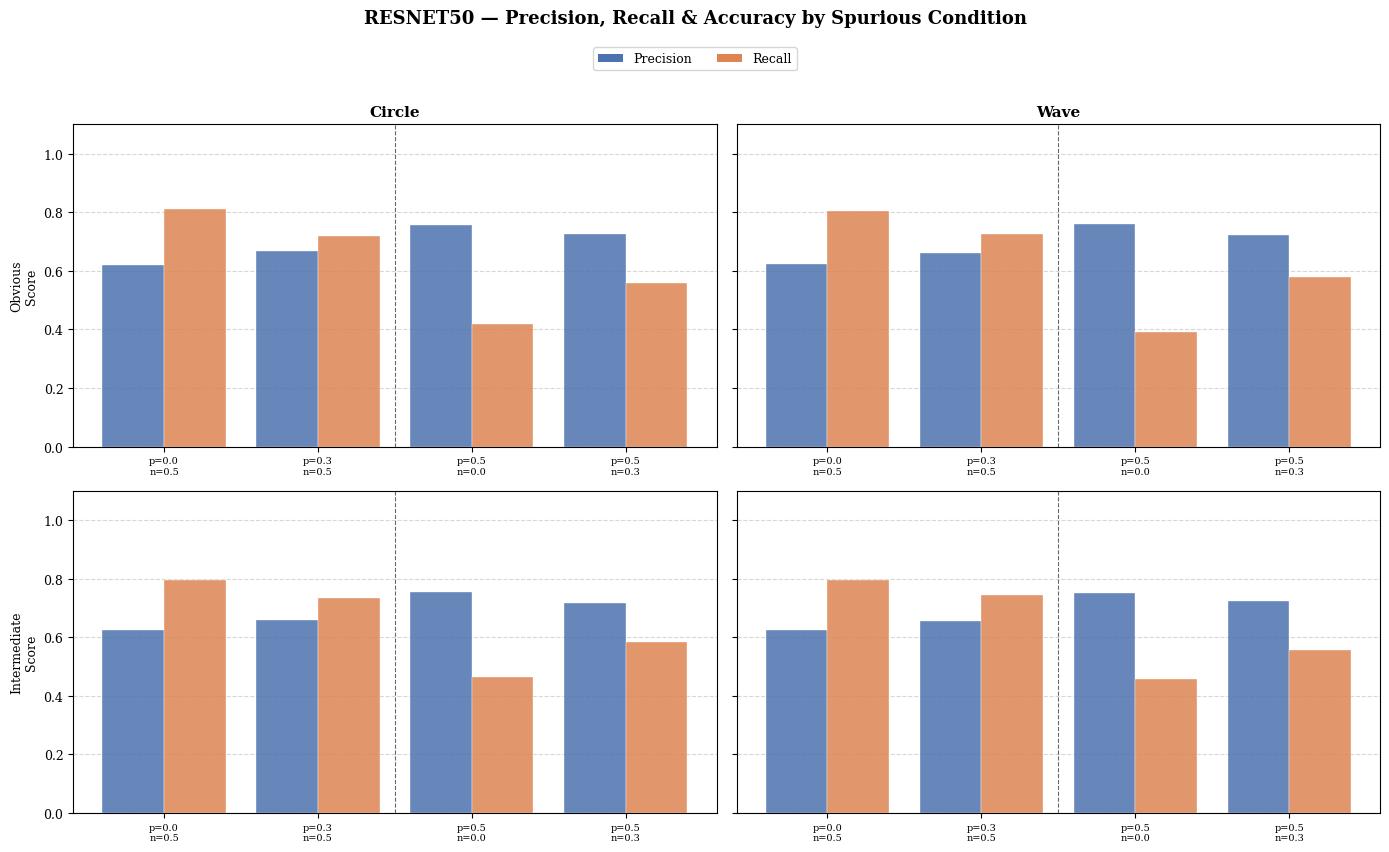

In [9]:
plot_model("resnet50")

saved: pr_collapse.png
saved: pr_collapse.pdf


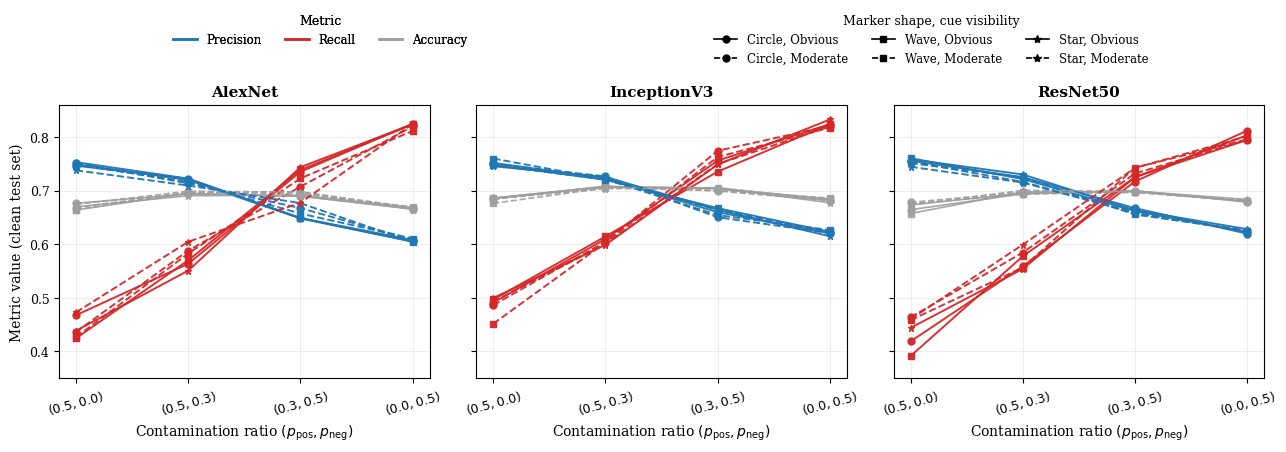

In [11]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


ARCHS = ["alexnet", "inceptionv3", "resnet50"]
ARCH_TITLES = {"alexnet": "AlexNet", "inceptionv3": "InceptionV3", "resnet50": "ResNet50"}
SHAPES = ["circle", "wave", "star"]
VISIBILITIES = ["obvious", "intermediate"]

VIS_DISPLAY = {"obvious": "Obvious", "intermediate": "Moderate"}
RATIOS = [("0.5", "0.0"), ("0.5", "0.3"), ("0.3", "0.5"), ("0.0", "0.5")]
RATIO_LABELS = [r"$(0.5, 0.0)$", r"$(0.5, 0.3)$", r"$(0.3, 0.5)$", r"$(0.0, 0.5)$"]

COL_ACC = "#9e9e9e"   # gray
COL_PREC = "#1f77b4"  # blue
COL_REC = "#d62728"   # red
LS_VIS = {"obvious": "-", "intermediate": "--"}
MK_SHAPE = {"circle": "o", "wave": "s", "star": "*"}


def make_figure(data, out_stem="pr_collapse"):
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8.5,
        "axes.linewidth": 0.8,
    })

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
    x = np.arange(len(RATIOS))

    for col, arch in enumerate(ARCHS):
        ax = axes[col]
        for shape in SHAPES:
            for vis in VISIBILITIES:
                keys = [f"{arch}_{shape}_{vis}_pos{r[0]}_neg{r[1]}" for r in RATIOS]
                missing = [k for k in keys if k not in data]
                if missing:
                    print(f"warning: missing keys {missing}", file=sys.stderr)
                    continue
                acc = [data[k]["accuracy"]  for k in keys]
                prec = [data[k]["precision"] for k in keys]
                rec = [data[k]["recall"]    for k in keys]
                ls = LS_VIS[vis]
                mk = MK_SHAPE[shape]
                ax.plot(x, acc,  color=COL_ACC,  linestyle=ls, marker=mk,
                        markersize=5, linewidth=1.2, alpha=0.9)
                ax.plot(x, prec, color=COL_PREC, linestyle=ls, marker=mk,
                        markersize=5, linewidth=1.4, alpha=0.95)
                ax.plot(x, rec,  color=COL_REC,  linestyle=ls, marker=mk,
                        markersize=5, linewidth=1.4, alpha=0.95)

        ax.set_title(ARCH_TITLES[arch], fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(RATIO_LABELS, rotation=15)
        ax.set_xlabel(r"Contamination ratio $(p_{\mathrm{pos}}, p_{\mathrm{neg}})$")
        ax.set_ylim(0.35, 0.86)
        ax.grid(alpha=0.25, linewidth=0.6)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("Metric value (clean test set)")

    metric_handles = [
        Line2D([0], [0], color=COL_PREC, lw=1.8, label="Precision"),
        Line2D([0], [0], color=COL_REC,  lw=1.8, label="Recall"),
        Line2D([0], [0], color=COL_ACC,  lw=1.8, label="Accuracy"),
    ]
    config_handles = [
        Line2D([0], [0], color="black", linestyle="-",  marker="o", markersize=5,
               lw=1.2, label=f"Circle, {VIS_DISPLAY['obvious']}"),
        Line2D([0], [0], color="black", linestyle="--", marker="o", markersize=5,
               lw=1.2, label=f"Circle, {VIS_DISPLAY['intermediate']}"),
        Line2D([0], [0], color="black", linestyle="-",  marker="s", markersize=5,
               lw=1.2, label=f"Wave, {VIS_DISPLAY['obvious']}"),
        Line2D([0], [0], color="black", linestyle="--", marker="s", markersize=5,
               lw=1.2, label=f"Wave, {VIS_DISPLAY['intermediate']}"),
        Line2D([0], [0], color="black", linestyle="-",  marker="*", markersize=6,
               lw=1.2, label=f"Star, {VIS_DISPLAY['obvious']}"),
        Line2D([0], [0], color="black", linestyle="--", marker="*", markersize=6,
               lw=1.2, label=f"Star, {VIS_DISPLAY['intermediate']}"),
    ]

    leg1 = fig.legend(handles=metric_handles, loc="upper center",
                      bbox_to_anchor=(0.25, 1.08), ncol=3, frameon=False,
                      title="Metric", title_fontsize=9)
    leg2 = fig.legend(handles=config_handles, loc="upper center",
                      bbox_to_anchor=(0.72, 1.08), ncol=3, frameon=False,
                      title="Marker shape, cue visibility", title_fontsize=9)
    fig.add_artist(leg1)  # ensure both legends survive tight_layout

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    png_path = f"{out_stem}.png"
    pdf_path = f"{out_stem}.pdf"
    plt.savefig(png_path, dpi=500, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    print(f"saved: {png_path}")
    print(f"saved: {pdf_path}")


def main():
    summary_path = "../results/summary.json"
    with open(summary_path) as f:
        data = json.load(f)
    # Drop any entries that came back as error dicts from run_training.
    data = {k: v for k, v in data.items() if "error" not in v}
    make_figure(data)


if __name__ == "__main__":
    main()